<a href="https://colab.research.google.com/github/siojzz/Practical-Statistics-for-Data-Scientists/blob/main/PracticalStatisticsChapter1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 - Exploratory Data Analysis

This notebook contains my code reproduction and notes for Chapter 1 of *Practical Statistics for Data Scientists*.

The chapter focuses on exploring and understanding data before doing further statistical analysis or modeling.


## 1. Elements of Structured Data

Data can come in many forms, but statistical analysis usually works with structured data.

The main types of structured data are:

- **Numeric data**
  - Continuous
  - Discrete
- **Categorical data**
  - Binary
  - Ordinal

Knowing the data type is important because it affects how the data can be analyzed and visualized.


## 2. Rectangular Data

A common data structure in data science is rectangular data.

It is organized using rows and columns, similar to a spreadsheet.

- **Rows** represent records or observations.
- **Columns** represent features or variables.
- **Outcome** is the variable that we want to predict in a predictive problem.

In Python, rectangular data is commonly stored using a pandas DataFrame.

In [ ]:
!pip install wquantiles

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wquantiles

from scipy.stats import trim_mean
from statsmodels import robust

In [ ]:
!wget https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv

--2026-09-29 08:32:02--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1457 (1.4K) [text/plain]
Saving to: ‘state.csv’

state.csv           100%[===================>]   1.42K  --.-KB/s    in 0s      

2026-09-29 08:32:02 (24.0 MB/s) - ‘state.csv’ saved [1457/1457]



In [ ]:
!pwd
!ls -l state.csv

/content
-rw-r--r-- 1 root root 1457 Sep 29 08:32 state.csv


In [ ]:
state = pd.read_csv("state.csv")
state.head(8)

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


## 3. Estimates of Location

Estimates of location are used to find a typical or central value in a dataset.

In this section, we will use mean, trimmed mean, median, weighted mean, and weighted median.

### 3.1 Mean

Mean is the average value of a dataset. It is calculated by adding all values and dividing by the number of observations.

Mean is simple to calculate, but it can be affected by extreme values.

In [ ]:
mean_population = state["Population"].mean()
mean_population

np.float64(6162876.3)

**Interpretation:**

The mean population is around 6.16 million people.

This means that the average population across all states in the dataset is about 6.16 million.

### 3.2 Trimmed Mean

Trimmed mean is calculated after removing some of the smallest and largest values.

This makes the result less affected by extreme values.

In [ ]:
trimmed_mean_population = trim_mean(state["Population"], 0.1)
trimmed_mean_population

np.float64(4783697.125)

**Interpretation:**

The trimmed mean population is around 4.78 million.

The value is lower than the regular mean because 10% of the smallest and largest observations are removed before calculating the average.

### 3.3 Median

Median is the middle value of the data after the values are sorted.

Compared with the mean, the median is less affected by extreme values or outliers.

In [ ]:
median_population = state["Population"].median()
median_population

4436369.5

**Interpretation:**

The median population is around 4.44 million people.

Half of the states have populations below this value, while the other half have populations above it.

In [ ]:
print("Mean:", mean_population)
print("Trimmed Mean:", trimmed_mean_population)
print("Median:", median_population)

Mean: 6162876.3
Trimmed Mean: 4783697.125
Median: 4436369.5


### Comparison

The mean gives the highest value, followed by the trimmed mean and the median.

This shows that states with very large populations have an effect on the regular mean. The trimmed mean and median are less sensitive to these extreme values.

### 3.4 Weighted Mean

A weighted mean gives different importance to each observation.

In this example, the murder rate is weighted by the population of each state. This means states with larger populations have a greater influence on the result.

In [ ]:
weighted_mean_murder = np.average(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_mean_murder

np.float64(4.445833981123393)

**Interpretation:**

The population-weighted average murder rate is about 4.45 murders per 100,000 people.

### 3.5 Weighted Median

Weighted median is similar to the regular median, but each value also has an associated weight.

For this calculation, population is used as the weight for the murder rate.

In [ ]:
weighted_median_murder = wquantiles.median(
    state["Murder.Rate"],
    weights=state["Population"]
)

weighted_median_murder

np.float64(4.4)

**Interpretation:**

The weighted median murder rate is 4.4.

The weighted mean and weighted median are very close for this dataset.

## 4. Estimates of Variability

Measures of variability describe how spread out the values are in a dataset.

Some common measures of variability are standard deviation, interquartile range (IQR), and median absolute deviation (MAD).

### 4.1 Standard Deviation

Standard deviation measures how far the values typically spread from the mean.

A larger standard deviation means the data values are more spread out.

In [ ]:
std_population = state["Population"].std()
std_population

6848235.347401142

**Interpretation:**

The standard deviation is around 6.85 million.

This indicates that state populations vary considerably around the average population.

### 4.2 Interquartile Range (IQR)

The interquartile range measures the spread of the middle 50% of the data.

It is calculated by subtracting the 25th percentile from the 75th percentile.

In [ ]:
iqr_population = (
    state["Population"].quantile(0.75)
    - state["Population"].quantile(0.25)
)

iqr_population

np.float64(4847308.0)

### 4.3 Median Absolute Deviation (MAD)

Median Absolute Deviation is a robust measure of variability based on the median.

It is less affected by extreme values compared with standard deviation.

In [ ]:
mad_population = robust.scale.mad(state["Population"])
mad_population

np.float64(3849876.1459979336)

**Interpretation:**

The MAD is around 3.85 million.

Compared with standard deviation, MAD is less affected by extreme population values, so it gives a more robust measure of variability.

## 5. Exploring the Data Distribution

After looking at location and variability, we can also examine how the values are distributed.

Some common tools for exploring a distribution are percentiles, boxplots, frequency tables, histograms, and density plots.

### 5.1 Percentiles

Percentiles show the value below which a certain percentage of observations fall.

They are useful for understanding the position and spread of values in a dataset.

In [ ]:
state["Murder.Rate"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


**Interpretation:**

The median murder rate is 4.0.

The 5th percentile is 1.6 and the 95th percentile is 6.51, showing that murder rates vary quite a lot across the states.

### 5.2 Boxplot

A boxplot is a simple way to visualize the distribution of numerical data.

The box represents the middle 50% of the data, while the line inside the box represents the median.

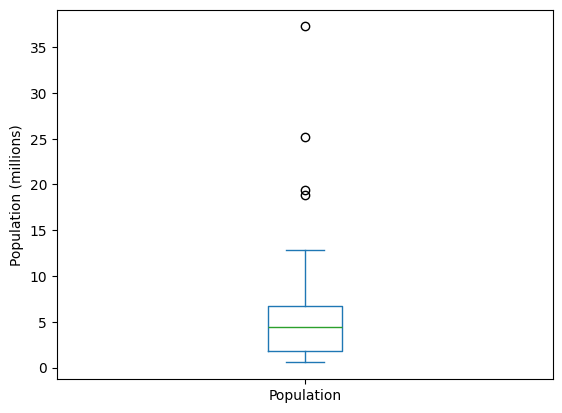

In [ ]:
ax = (state["Population"] / 1_000_000).plot.box()

ax.set_ylabel("Population (millions)")
plt.show()

**Interpretation:**

The boxplot shows that most state populations are concentrated at the lower values.

There are also several states with much larger populations that appear as outliers.

### 5.3 Frequency Table

A frequency table divides numerical values into intervals or bins and counts how many observations fall into each interval.

This makes it easier to see how the data is distributed.

In [ ]:
binned_population = pd.cut(state["Population"], 10)
binned_population.value_counts().sort_index()

,count
Population,
"(526935.67, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(26246857.0, 29915890.0]",0
"(29915890.0, 33584923.0]",0


**Interpretation:**

Most states are located in the lower population ranges.

Only a small number of states are found in the highest population intervals.

### 5.4 Histogram

A histogram visualizes a frequency distribution using bars.

Each bar represents an interval of numerical values and shows how many observations fall inside that interval.

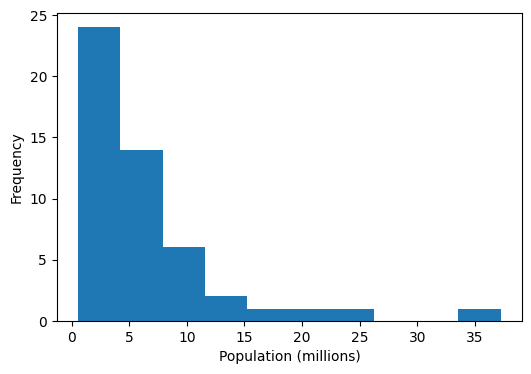

In [ ]:
ax = (state["Population"] / 1_000_000).plot.hist(figsize=(6, 4))

ax.set_xlabel("Population (millions)")
ax.set_ylabel("Frequency")

plt.show()

**Interpretation:**

The histogram shows that most states have relatively small populations, while only a few states have very large populations.

This indicates that the population distribution is skewed toward higher values.

### 5.5 Density Plot

A density plot shows the distribution of numerical data as a smooth curve.

It can be seen as a smoothed version of a histogram and is useful for understanding the overall shape of the distribution.

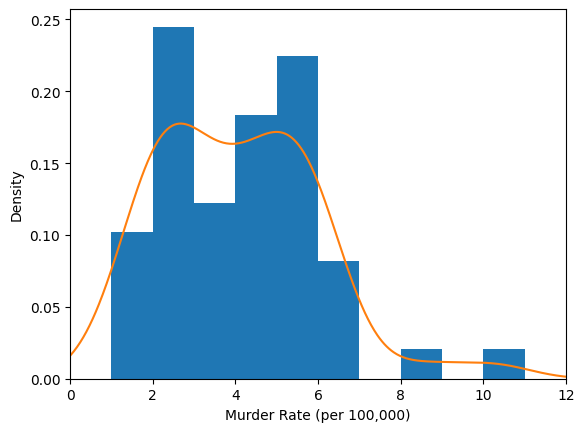

In [ ]:
ax = state["Murder.Rate"].plot.hist(
    density=True,
    xlim=[0, 12],
    bins=range(1, 12)
)

state["Murder.Rate"].plot.density(ax=ax)

ax.set_xlabel("Murder Rate (per 100,000)")
plt.show()

**Interpretation:**

The density curve shows how murder rates are distributed across the states.

Most values are concentrated in the middle range, while fewer states have very low or very high murder rates.

## 6. Exploring Binary and Categorical Data

Categorical data is usually summarized using counts, proportions, or percentages.

Some common ways to explore categorical data are mode, expected value, bar charts, and pie charts.

In [ ]:
!wget https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/dfw_airline.csv

--2026-09-29 09:01:10--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/dfw_airline.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 90 [text/plain]
Saving to: ‘dfw_airline.csv’

dfw_airline.csv     100%[===================>]      90  --.-KB/s    in 0s      

2026-09-29 09:01:10 (1.78 MB/s) - ‘dfw_airline.csv’ saved [90/90]



In [ ]:
dfw = pd.read_csv("dfw_airline.csv")
dfw

,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


### 6.1 Bar Chart

A bar chart is commonly used to visualize categorical data.

Each bar represents a category, and the height of the bar shows its frequency or count.

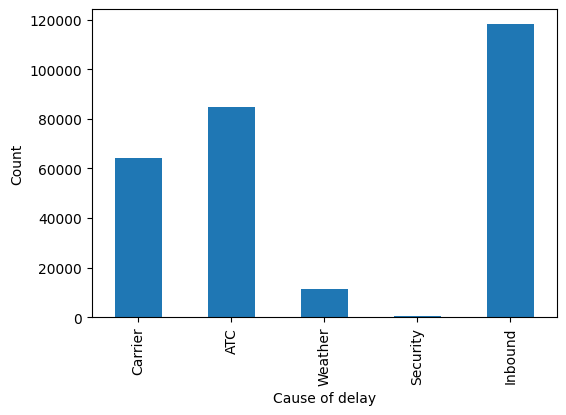

In [ ]:
ax = dfw.transpose().plot.bar(
    figsize=(6, 4),
    legend=False
)

ax.set_xlabel("Cause of delay")
ax.set_ylabel("Count")

plt.show()

**Interpretation:**

Inbound delays have the highest count, followed by ATC and carrier-related delays.

Security delays have the lowest count among the categories.

### 6.2 Mode

Mode is the category or value that appears most often in a dataset.

For the DFW airline delay data, the category with the highest frequency is Inbound.

In [ ]:
dfw.transpose()[0].idxmax()

'Inbound'

### 6.3 Expected Value

Expected value represents the average result we would expect when each possible outcome has a probability.

It is calculated by multiplying each outcome by its probability and then adding the results.

In [ ]:
expected_value = (
    0.05 * 300
    + 0.15 * 50
    + 0.80 * 0
)

expected_value

22.5

**Interpretation:**

The expected value is 22.5.

This means one webinar attendee is expected to generate an average monthly value of $22.50 based on the given probabilities.

### 6.4 Probability

Probability describes how likely an event is to occur.

A probability ranges from 0 to 1, where 0 means the event will not occur and 1 means the event is certain.

## 7. Correlation

Correlation measures how strongly two numerical variables are related.

The correlation coefficient ranges from -1 to +1:

- **+1** means a perfect positive relationship.
- **0** means no linear correlation.
- **-1** means a perfect negative relationship.

In [ ]:
!wget https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_px.csv
!wget https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_sym.csv

--2026-09-29 11:36:27--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_px.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-29 11:36:27 ERROR 404: Not Found.

--2026-09-29 11:36:27--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_sym.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-29 11:36:27 ERROR 404: Not Found.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!wget -O sp500_data.csv.gz https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz

--2026-10-01 06:21:34--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21152050 (20M) [application/octet-stream]
Saving to: ‘sp500_data.csv.gz’

sp500_data.csv.gz   100%[===================>]  20.17M  --.-KB/s    in 0.1s    

2026-10-01 06:21:35 (139 MB/s) - ‘sp500_data.csv.gz’ saved [21152050/21152050]



In [4]:
sp500_px = pd.read_csv(
    "sp500_data.csv.gz",
    index_col=0
)

sp500_px.index = pd.to_datetime(sp500_px.index)

sp500_px.head()

,ADS,CA,MSFT,RHT,CTSH,CSC,EMC,IBM,XRX,ALTR,...,WAT,ALXN,AMGN,BXLT,BIIB,CELG,GILD,REGN,VRTX,HSIC
1993-01-29,0.0,0.060124,-0.022100,0.0,0.0,0.018897,0.007368,0.092165,0.259140,-0.007105,...,0.0,0.0,0.34716,0.0,0.04167,0.00000,0.015564,1.75,0.1250,0.0
1993-02-01,0.0,-0.180389,0.027621,0.0,0.0,0.018889,0.018425,0.115207,-0.100775,0.063893,...,0.0,0.0,-0.23144,0.0,0.00000,-0.01041,0.007782,1.25,0.1250,0.0
1993-02-02,0.0,-0.120257,0.035900,0.0,0.0,-0.075573,0.029482,-0.023041,0.028796,-0.014192,...,0.0,0.0,-0.11572,0.0,0.00000,0.00000,-0.007792,-0.25,0.0000,0.0
1993-02-03,0.0,0.060124,-0.024857,0.0,0.0,-0.151128,0.003689,-0.253454,-0.043190,-0.007105,...,0.0,0.0,-0.08679,0.0,0.04167,-0.04167,-0.038919,-0.50,0.0625,0.0
1993-02-04,0.0,-0.360770,-0.060757,0.0,0.0,0.113350,-0.022114,0.069862,0.000000,-0.007096,...,0.0,0.0,0.14465,0.0,-0.04166,-0.03126,-0.046711,0.00,0.0625,0.0


### 7.1 Correlation Matrix

A correlation matrix shows the relationship between several numerical variables.

The correlation value ranges from -1 to +1. Values close to +1 indicate a strong positive relationship, while values close to -1 indicate a strong negative relationship.

In [5]:
etf_symbols = ["SPY", "DIA", "QQQ", "XLK", "GLD", "USO", "VXX"]

etfs = sp500_px.loc[
    sp500_px.index > "2012-07-01",
    etf_symbols
]

etfs.corr()

,SPY,DIA,QQQ,XLK,GLD,USO,VXX
SPY,1.000000,0.953726,0.908995,0.886588,0.078722,0.272069,-0.547074
DIA,0.953726,1.000000,0.834440,0.842757,0.051523,0.256793,-0.511327
QQQ,0.908995,0.834440,1.000000,0.945126,0.043553,0.199492,-0.470555
XLK,0.886588,0.842757,0.945126,1.000000,0.053022,0.225962,-0.477258
GLD,0.078722,0.051523,0.043553,0.053022,1.000000,0.216563,-0.107488
USO,0.272069,0.256793,0.199492,0.225962,0.216563,1.000000,-0.195397
VXX,-0.547074,-0.511327,-0.470555,-0.477258,-0.107488,-0.195397,1.000000


### 7.2 Correlation Heatmap

A heatmap makes the correlation matrix easier to understand visually.

The color and value in each cell show the strength and direction of the relationship between two variables.

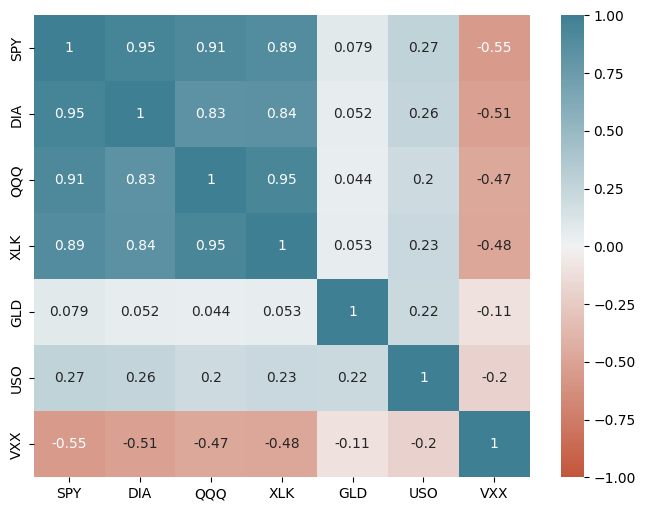

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    etfs.corr(),
    vmin=-1,
    vmax=1,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    annot=True
)

plt.show()

**Interpretation:**

Some ETFs have strong positive correlations, which means their returns tend to move in the same direction.

Other ETFs have weaker or negative correlations, which means their movements are less similar.

In [ ]:
### 7.3 Scatterplot

A scatterplot is used to visualize the relationship between two numerical variables.

Each point represents one observation.

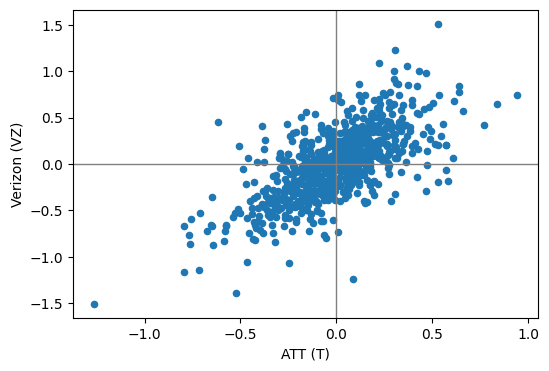

In [7]:
telecom = sp500_px.loc[
    sp500_px.index > "2012-07-01",
    ["T", "VZ"]
]

ax = telecom.plot.scatter(
    x="T",
    y="VZ",
    figsize=(6, 4)
)

ax.set_xlabel("ATT (T)")
ax.set_ylabel("Verizon (VZ)")
ax.axhline(0, color="grey", lw=1)
ax.axvline(0, color="grey", lw=1)

plt.show()

In [ ]:
**Interpretation:**

The scatterplot shows a positive relationship between ATT and Verizon returns.

Many points move in the same direction, indicating that the two stocks are positively correlated.

## 8. Exploring Two or More Variables

So far, most of the analysis has focused on one or two variables.

This section explores relationships involving multiple variables using different statistical summaries and visualizations.

### 8.1 Hexagonal Binning

A scatterplot can become difficult to read when a dataset contains many observations.

Hexagonal binning groups observations into hexagonal areas, making it easier to see the density and relationship between two numerical variables.

In [8]:
!wget -O kc_tax.csv.gz https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/kc_tax.csv.gz

--2026-10-01 06:26:20--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/kc_tax.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2346023 (2.2M) [application/octet-stream]
Saving to: ‘kc_tax.csv.gz’

kc_tax.csv.gz       100%[===================>]   2.24M  --.-KB/s    in 0.07s   

2026-10-01 06:26:20 (32.7 MB/s) - ‘kc_tax.csv.gz’ saved [2346023/2346023]



In [9]:
kc_tax = pd.read_csv("kc_tax.csv.gz")

kc_tax.head()

,TaxAssessedValue,SqFtTotLiving,ZipCode
0,NaN,1730,98117.0
1,206000.0,1870,98002.0
2,303000.0,1530,98166.0
3,361000.0,2000,98108.0
4,459000.0,3150,98108.0


In [10]:
kc_tax0 = kc_tax.loc[
    (kc_tax["TaxAssessedValue"] < 750000) &
    (kc_tax["SqFtTotLiving"] > 100) &
    (kc_tax["SqFtTotLiving"] < 3500),
    :
]

kc_tax0.shape

(432693, 3)

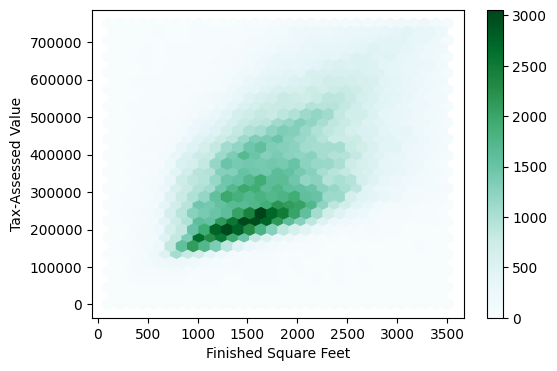

In [11]:
ax = kc_tax0.plot.hexbin(
    x="SqFtTotLiving",
    y="TaxAssessedValue",
    gridsize=30,
    sharex=False,
    figsize=(6, 4)
)

ax.set_xlabel("Finished Square Feet")
ax.set_ylabel("Tax-Assessed Value")

plt.show()

**Interpretation:**

The hexagonal binning plot shows a positive relationship between house size and tax-assessed value.

In general, larger houses tend to have higher tax-assessed values. The denser hexagons show where most observations are concentrated.

### 8.2 Two Categorical Variables

A contingency table is useful for summarizing the relationship between two categorical variables.

It shows how many observations fall into each combination of categories.

In [12]:
!wget -O lc_loans.csv https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/lc_loans.csv

--2026-10-01 06:29:51--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/lc_loans.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4862888 (4.6M) [text/plain]
Saving to: ‘lc_loans.csv’

lc_loans.csv        100%[===================>]   4.64M  --.-KB/s    in 0.05s   

2026-10-01 06:29:51 (84.5 MB/s) - ‘lc_loans.csv’ saved [4862888/4862888]



In [13]:
lc_loans = pd.read_csv("lc_loans.csv")
lc_loans.head()

,status,grade
0,Fully Paid,B
1,Charged Off,C
2,Fully Paid,C
3,Fully Paid,C
4,Current,B


In [14]:
crosstab = lc_loans.pivot_table(
    index="grade",
    columns="status",
    aggfunc=lambda x: len(x),
    margins=True
)

crosstab

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


**Interpretation:**

The contingency table shows the number of loans for each combination of loan grade and loan status.

Higher loan grades generally have fewer late or charged-off loans compared with lower grades.

### 8.3 Categorical and Numeric Data

Boxplots can be used to compare a numerical variable across different categories.

In this example, we compare the percentage of carrier-related flight delays across airlines.

In [15]:
!wget -O airline_stats.csv https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/airline_stats.csv

--2026-10-01 06:30:26--  https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/airline_stats.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1784825 (1.7M) [text/plain]
Saving to: ‘airline_stats.csv’

airline_stats.csv   100%[===================>]   1.70M  --.-KB/s    in 0.04s   

2026-10-01 06:30:27 (40.5 MB/s) - ‘airline_stats.csv’ saved [1784825/1784825]



In [16]:
airline_stats = pd.read_csv("airline_stats.csv")
airline_stats.head()

,pct_carrier_delay,pct_atc_delay,pct_weather_delay,airline
0,8.153226,1.971774,0.762097,American
1,5.959924,3.706107,1.585878,American
2,7.157270,2.706231,2.026706,American
3,12.100000,11.033333,0.000000,American
4,7.333333,3.365591,1.774194,American


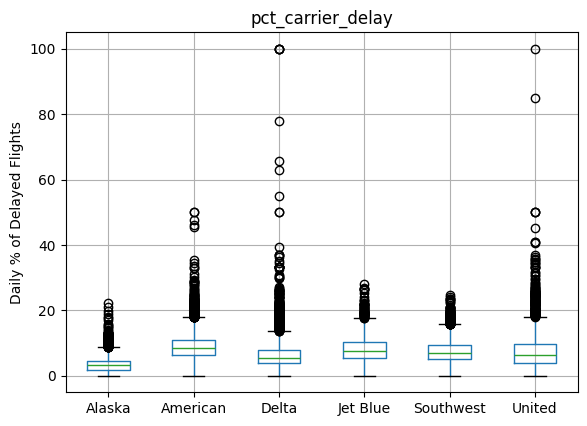

In [17]:
ax = airline_stats.boxplot(
    by="airline",
    column="pct_carrier_delay"
)

ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")
plt.suptitle("")
plt.show()

**Interpretation:**

The boxplot shows differences in carrier-related delays between airlines.

Some airlines have consistently lower delay percentages, while others show higher values and greater variability.

In [ ]:
### Violin Plot

A violin plot is similar to a boxplot, but it also shows the shape and density of the data distribution.

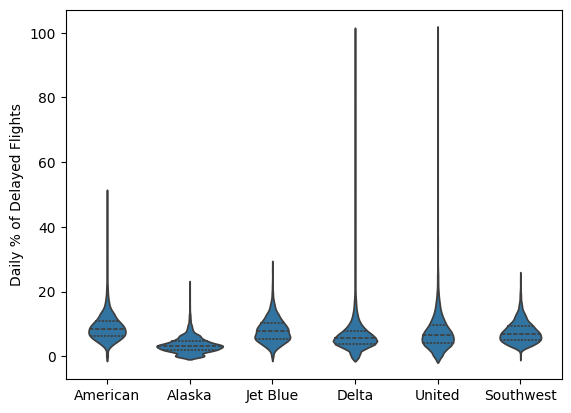

In [18]:
ax = sns.violinplot(
    data=airline_stats,
    x="airline",
    y="pct_carrier_delay",
    inner="quartile"
)

ax.set_xlabel("")
ax.set_ylabel("Daily % of Delayed Flights")

plt.show()

### 8.4 Visualizing Multiple Variables

Multiple variables can be explored by dividing the data into groups and creating separate visualizations for each group.

In this example, house size and tax-assessed value are compared across several zip codes.

In [19]:
zip_codes = [98188, 98105, 98108, 98126]

kc_tax_zip = kc_tax0.loc[
    kc_tax0["ZipCode"].isin(zip_codes),
    :
]

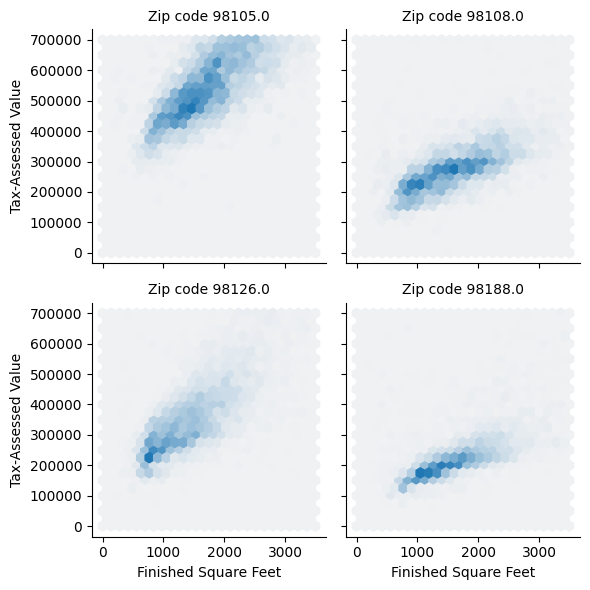

In [20]:
def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(
        x,
        y,
        gridsize=25,
        cmap=cmap,
        **kwargs
    )

g = sns.FacetGrid(
    kc_tax_zip,
    col="ZipCode",
    col_wrap=2
)

g.map(
    hexbin,
    "SqFtTotLiving",
    "TaxAssessedValue",
    extent=[0, 3500, 0, 700000]
)

g.set_axis_labels(
    "Finished Square Feet",
    "Tax-Assessed Value"
)

g.set_titles("Zip code {col_name}")

plt.show()

**Interpretation:**

The relationship between house size and tax-assessed value is different across zip codes.

Location therefore provides additional information that is not visible when all observations are plotted together.

## 9. Chapter Summary

In this chapter, I learned the basic concepts of Exploratory Data Analysis (EDA).

The main topics covered were:

- Structured and rectangular data
- Estimates of location such as mean, median, and weighted mean
- Measures of variability such as standard deviation, IQR, and MAD
- Percentiles and data distributions
- Boxplots, histograms, and density plots
- Categorical data and bar charts
- Correlation and scatterplots
- Hexagonal binning and contingency tables
- Comparing categorical and numerical variables
- Visualizing relationships between multiple variables

These techniques are useful for understanding the characteristics and relationships in a dataset before moving to statistical modeling or machine learning.